In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content
!rm -rf cdt-alzheimer-screening
!git clone https://github.com/wiambenadder/cdt-alzheimer-screening.git
%cd cdt-alzheimer-screening
!pip install -q -r requirements.txt

Mounted at /content/drive
/content
Cloning into 'cdt-alzheimer-screening'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 44 (delta 10), reused 26 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 36.86 KiB | 12.29 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/cdt-alzheimer-screening
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.3 MB/s eta 0:00:00


In [2]:
import sys, importlib
sys.path.insert(0, '/content/cdt-alzheimer-screening')

import src.config as cfg
from pathlib import Path

cfg.LABELS_CSV     = Path('/content/drive/MyDrive/cdt-data/labels.csv')
cfg.RAW_IMAGES_DIR = Path('/content/drive/MyDrive/cdt-data/nhats_raw')
cfg.MODELS_DIR     = Path('/content/drive/MyDrive/cdt-data/models')
cfg.RESULTS_DIR    = Path('/content/drive/MyDrive/cdt-data/results')
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Labels CSV:", cfg.LABELS_CSV, "exists:", cfg.LABELS_CSV.exists())
print("Models dir:", cfg.MODELS_DIR)
print("Results dir:", cfg.RESULTS_DIR)

Labels CSV: /content/drive/MyDrive/cdt-data/labels.csv exists: True
Models dir: /content/drive/MyDrive/cdt-data/models
Results dir: /content/drive/MyDrive/cdt-data/results


In [3]:
import pandas as pd
df = pd.read_csv(cfg.LABELS_CSV)

print(f"Total labeled clocks: {len(df):,}")
print(f"Unique participants: {df['participant_id'].nunique():,}")
print(f"Rounds covered: {sorted(df['round'].unique())}")
print(f"\nFirst 5 rows:")
df.head()

Total labeled clocks: 59,417
Unique participants: 13,642
Rounds covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

First 5 rows:


,round,participant_id,cdt_score,image_path
0,1,10000003,3,/content/drive/MyDrive/cdt-data/nhats_raw/roun...
1,1,10000004,3,/content/drive/MyDrive/cdt-data/nhats_raw/roun...
2,1,10000005,3,/content/drive/MyDrive/cdt-data/nhats_raw/roun...
3,1,10000006,4,/content/drive/MyDrive/cdt-data/nhats_raw/roun...
4,1,10000008,2,/content/drive/MyDrive/cdt-data/nhats_raw/roun...


In [4]:
# we copy all per-round folders to local SSD.
# so that we save up time during the training.
import shutil, os

LOCAL_DATA_DIR = Path('/content/nhats_local')
LOCAL_DATA_DIR.mkdir(exist_ok=True)

import time
t0 = time.time()

for round_folder in sorted(cfg.RAW_IMAGES_DIR.iterdir()):
    if not round_folder.is_dir():
        continue
    dst = LOCAL_DATA_DIR / round_folder.name
    if dst.exists() and len(list(dst.glob('*.tif'))) > 0:
        print(f"[skip] {round_folder.name} already staged ({len(list(dst.glob('*.tif'))):,} files)")
        continue
    print(f"[copy] {round_folder.name} -> local...")
    shutil.copytree(round_folder, dst, dirs_exist_ok=True)

print(f"\n[done] staging finished in {(time.time()-t0)/60:.1f} min")
print(f"Total local TIFFs: {sum(1 for _ in LOCAL_DATA_DIR.rglob('*.tif')):,}")

[copy] round_01 -> local...
[copy] round_02 -> local...
[copy] round_03 -> local...
[copy] round_04 -> local...
[copy] round_05 -> local...
[copy] round_06 -> local...
[copy] round_07 -> local...
[copy] round_08 -> local...
[copy] round_09 -> local...
[copy] round_10 -> local...
[copy] round_11 -> local...
[copy] round_12 -> local...
[copy] round_13 -> local...
[copy] round_14 -> local...

[done] staging finished in 51.8 min
Total local TIFFs: 73,769


In [5]:
# we rewrite the image_path to point at local copies instead of the drive
# we save this as a separate file so the original Drive labels.csv stays intact
df_local = df.copy()
df_local['image_path'] = df_local['image_path'].str.replace(
    '/content/drive/MyDrive/cdt-data/nhats_raw/',
    '/content/nhats_local/',
    regex=False,
)

LOCAL_LABELS = Path('/content/cdt_labels_local.csv')
df_local.to_csv(LOCAL_LABELS, index=False)

# we verify a random image actually opens from the new local path
from PIL import Image
sample_path = df_local.iloc[0]['image_path']
img = Image.open(sample_path)
print(f"Sample path: {sample_path}")
print(f"Image mode: {img.mode}, size: {img.size}")
print(f"[ok] Rewrote {len(df_local):,} paths to local copy -> {LOCAL_LABELS}")

# we repoint config to the local labels file
cfg.LABELS_CSV = LOCAL_LABELS

Sample path: /content/nhats_local/round_01/10000003.tif
Image mode: 1, size: (2560, 3312)
[ok] Rewrote 59,417 paths to local copy -> /content/cdt_labels_local.csv


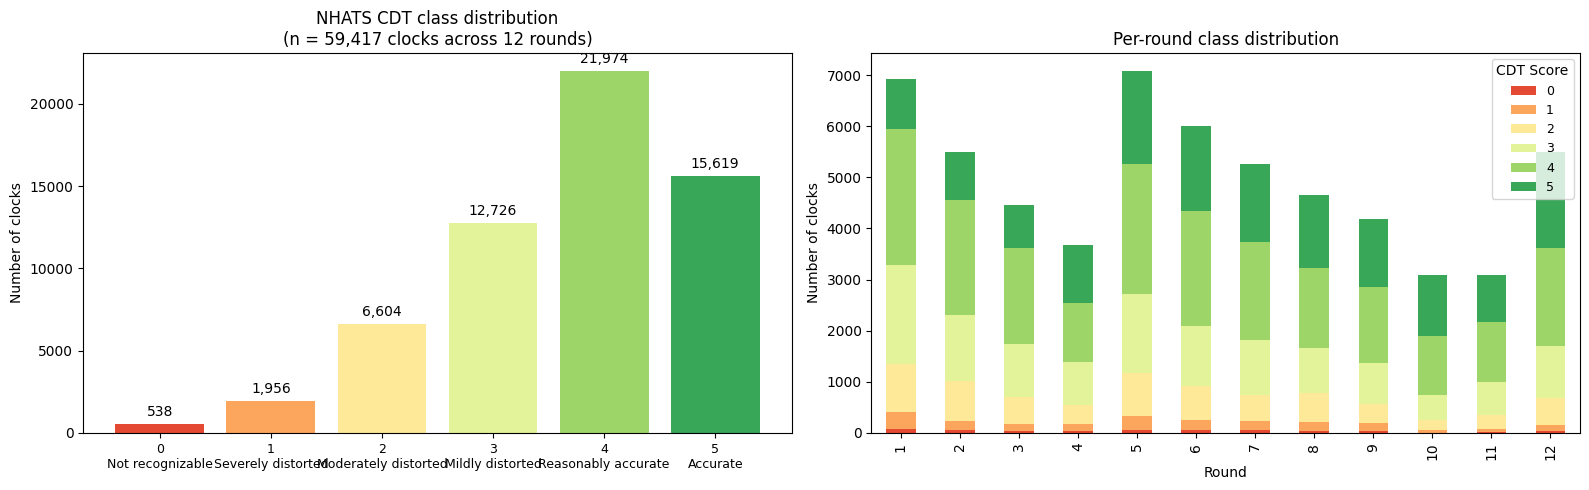


Imbalance ratio (largest class : smallest class): 40.8 : 1
This is a heavily imbalanced task — class-weighted loss is essential.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    '0\nNot recognizable',
    '1\nSeverely distorted',
    '2\nModerately distorted',
    '3\nMildly distorted',
    '4\nReasonably accurate',
    '5\nAccurate',
]

counts = df['cdt_score'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# the raw counts
ax1.bar(range(6), counts.values, color=sns.color_palette('RdYlGn', 6))
ax1.set_xticks(range(6))
ax1.set_xticklabels(class_names, fontsize=9)
ax1.set_ylabel('Number of clocks')
ax1.set_title(f'NHATS CDT class distribution\n(n = {len(df):,} clocks across {df["round"].nunique()} rounds)')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# the per-round stacked
round_class = df.groupby(['round', 'cdt_score']).size().unstack(fill_value=0)
round_class.plot(kind='bar', stacked=True, ax=ax2,
                 color=sns.color_palette('RdYlGn', 6))
ax2.set_xlabel('Round')
ax2.set_ylabel('Number of clocks')
ax2.set_title('Per-round class distribution')
ax2.legend(title='CDT Score', labels=[f'{i}' for i in range(6)],
           loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# to report the imbalance ratio (I should use that in the discussion)
print(f"\nImbalance ratio (largest class : smallest class): "
      f"{counts.max() / counts.min():.1f} : 1")
print(f"This is a heavily imbalanced task — class-weighted loss is essential.")

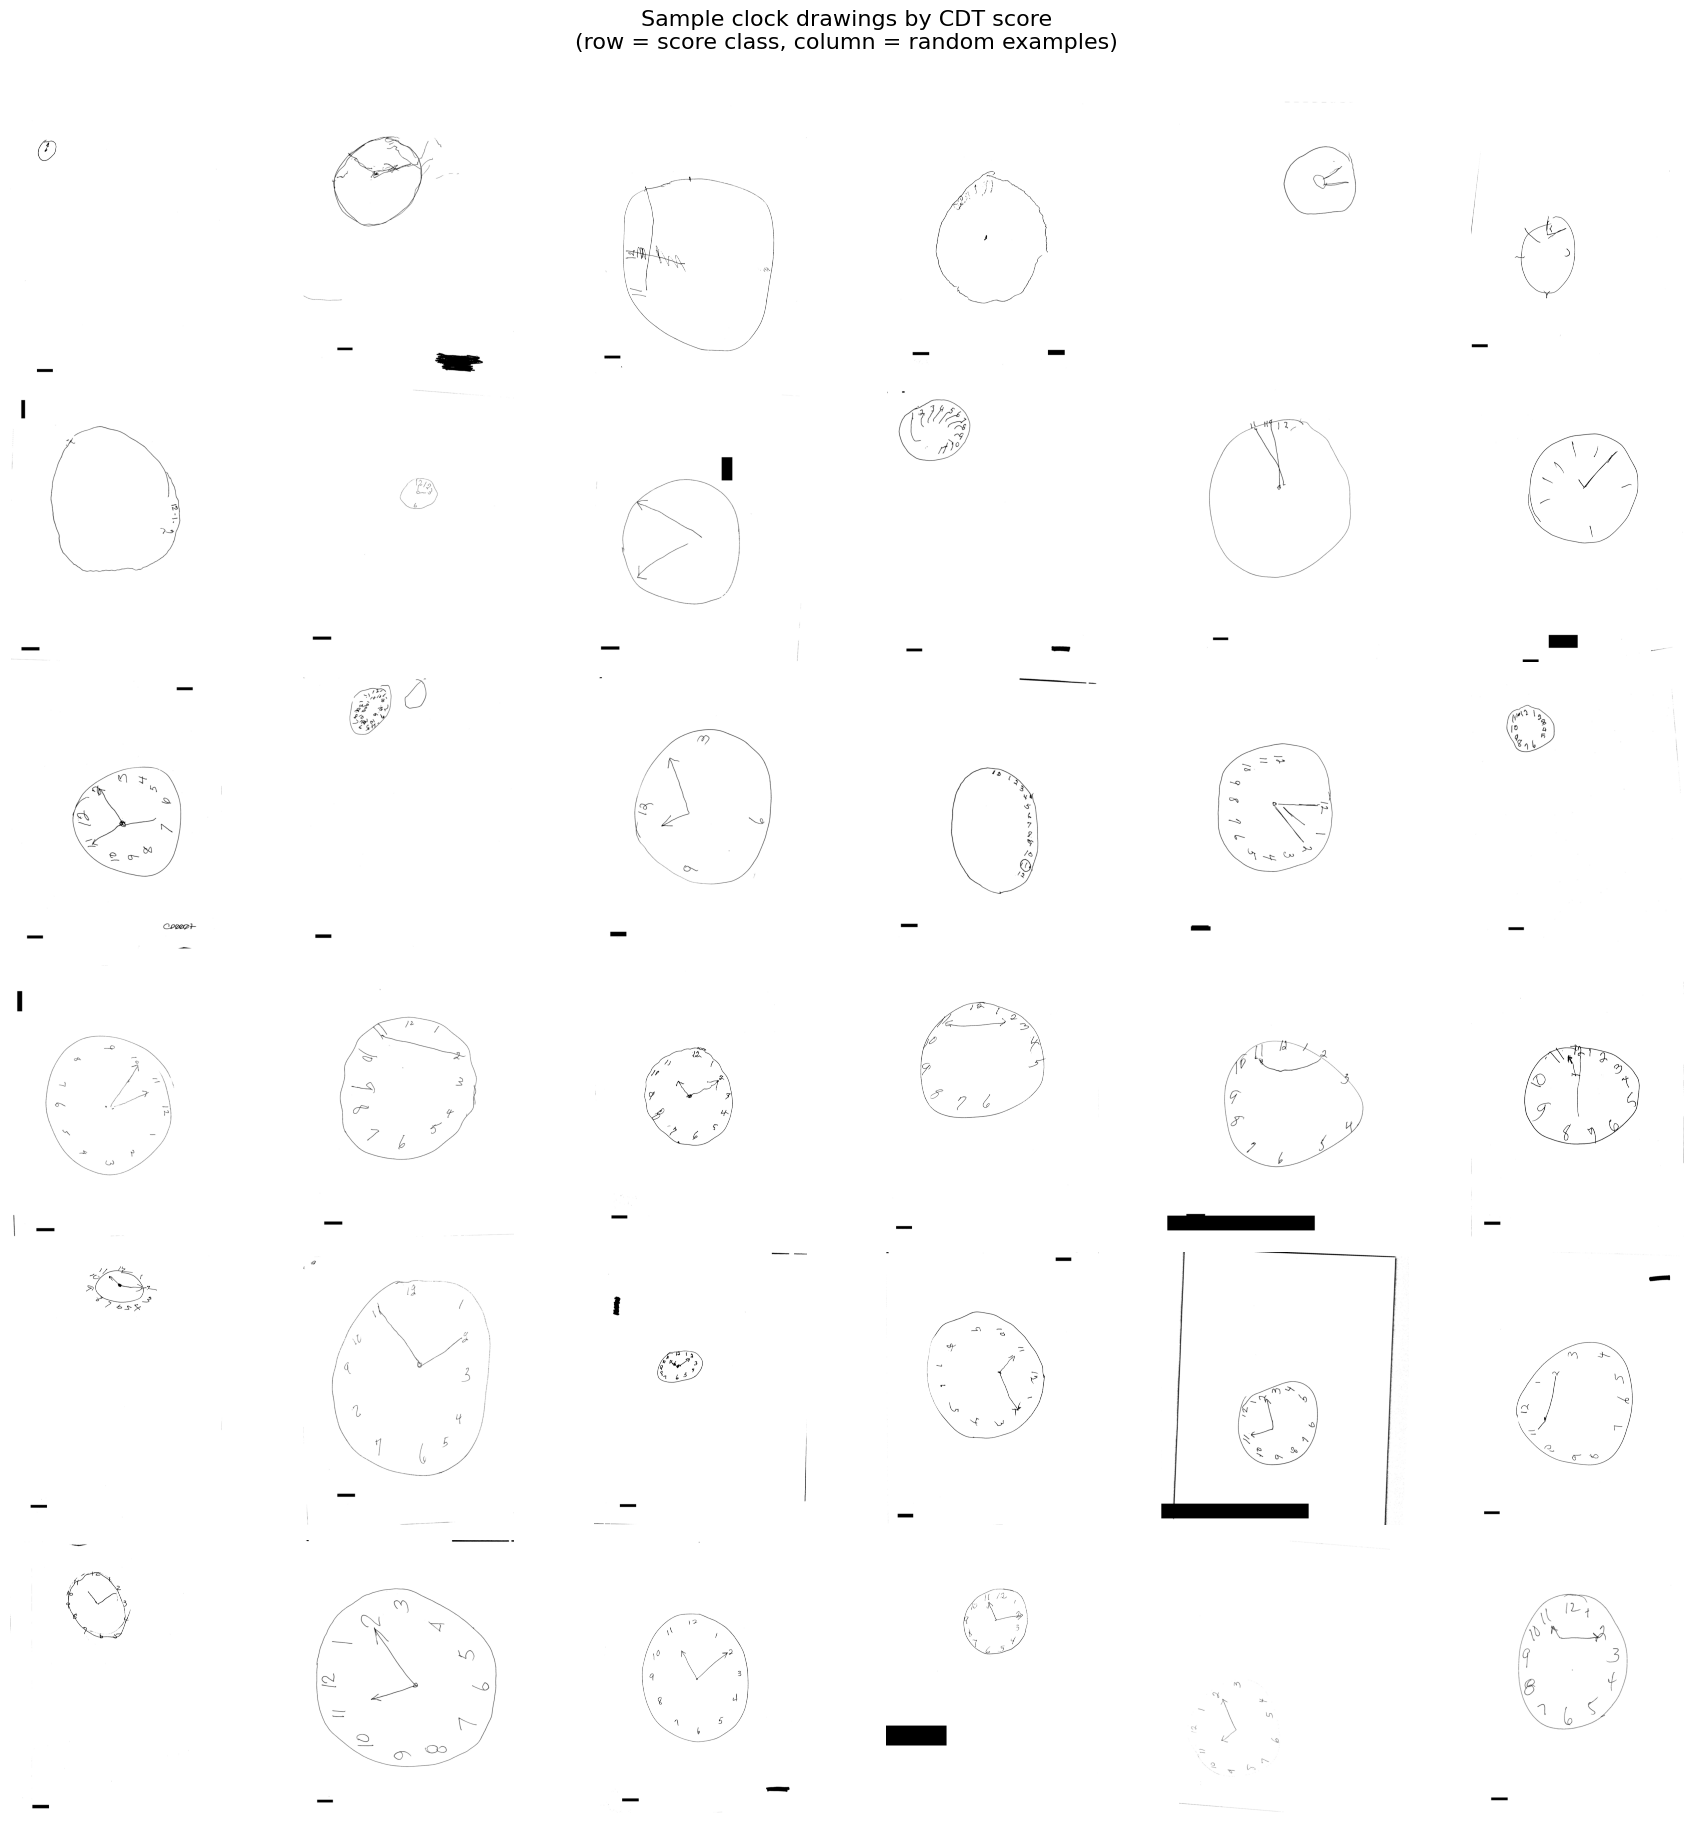

In [7]:
import random
from PIL import Image
random.seed(42)

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
for score in range(6):
    subset = df[df['cdt_score'] == score]
    samples = subset.sample(n=min(6, len(subset)), random_state=score)
    # we use the LOCAL paths
    samples_local = samples.copy()
    samples_local['image_path'] = samples_local['image_path'].str.replace(
        '/content/drive/MyDrive/cdt-data/nhats_raw/',
        '/content/nhats_local/', regex=False,
    )
    for col, (_, row) in enumerate(samples_local.iterrows()):
        ax = axes[score, col]
        try:
            img = Image.open(row['image_path']).convert('L')
            ax.imshow(img, cmap='gray')
        except Exception as e:
            ax.text(0.5, 0.5, f'err: {e}', ha='center')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Score {score}', fontsize=14, rotation=0, labelpad=60)

plt.suptitle('Sample clock drawings by CDT score\n(row = score class, column = random examples)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'sample_clocks_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# we check image size variation
# to check if we need to resize during the preprocessing
import numpy as np
sample_sizes = []
sample = df.sample(n=500, random_state=42)
for _, row in sample.iterrows():
    local_path = row['image_path'].replace(
        '/content/drive/MyDrive/cdt-data/nhats_raw/', '/content/nhats_local/'
    )
    try:
        img = Image.open(local_path)
        sample_sizes.append(img.size)
    except Exception:
        pass

widths  = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]

print(f"Sampled {len(sample_sizes)} images")
print(f"Width  range: {min(widths):>5} .. {max(widths):>5}  (median: {int(np.median(widths))})")
print(f"Height range: {min(heights):>5} .. {max(heights):>5}  (median: {int(np.median(heights))})")
print(f"\nThis Justifies our Resize((224,224)) preprocessing step — source images vary in size.")

Sampled 500 images
Width  range:  1696 ..  3424  (median: 2560)
Height range:  2208 ..  4400  (median: 3312)

This Justifies our Resize((224,224)) preprocessing step — source images vary in size.


In [9]:
# we build the loaders to make sure everything is working
from src.data import CDTDataset, stratified_split, compute_class_weights
from src.config import DataConfig
from src.augmentation import build_train_transform, build_eval_transform, AugConfig

data_cfg = DataConfig(batch_size=16, num_workers=2)
aug_cfg  = AugConfig()

# we have a ready to go df with image_path + label columns, so we just rename and pass in
df_ready = df_local.rename(columns={'cdt_score': 'label'})[['participant_id', 'label', 'image_path']]

train_df, val_df, test_df = stratified_split(df_ready, data_cfg)
class_weights = compute_class_weights(train_df)
print(f"Class weights: {class_weights.tolist()}")

# we create the dataset and pull out one batch
train_ds = CDTDataset(train_df.head(64),
                      transform=build_train_transform(224, aug_cfg, use_aug=True))
from torch.utils.data import DataLoader
loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
imgs, labels = next(iter(loader))
print(f"\nBatch tensor shape: {imgs.shape}  (should be [16, 3, 224, 224])")
print(f"Labels in batch: {labels.tolist()}")
print(f"\n[ok] Pipeline ready for training notebooks.")

[split] train=41591  val=8913  test=8913
Class weights: [18.386825561523438, 5.0634284019470215, 1.4994231462478638, 0.7781581878662109, 0.4506750702857971, 0.6340284943580627]

Batch tensor shape: torch.Size([16, 3, 224, 224])  (should be [16, 3, 224, 224])
Labels in batch: [5, 2, 3, 5, 4, 5, 1, 5, 3, 3, 5, 4, 2, 3, 4, 4]

[ok] Pipeline ready for training notebooks.
